# EFM Generation: Colored MNIST 32x32

In [1]:
import torch
import torchvision

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import wandb
import sys
sys.path.append("/home/windowskonon1337/sources/FieldMatching")
from src.models import DDPM, ExponentialMovingAverage
from src.efm_field import EFM
from src.utils import Config, optimization_manager, random_color

/home/windowskonon1337/sources/FieldMatching/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Base Config

In [2]:
config = Config()

config.data = Config()
config.data.name = 'CMNIST'
config.data.num_channels = 3
config.data.img_resize = 32
config.data.image_size=32
config.data.centered = True

config.device = 'cuda'
config.L = 500 # important parameter
config.DIM = config.data.num_channels*config.data.image_size*config.data.image_size + 1

config.p = Config()
config.p.x_loc = 0.

config.q = Config()
config.q.x_loc = config.L


config.training = Config()
config.training.small_batch_size =32 # important parameter
config.training.batch_size =32      # important parameter
config.training.n_iters = 1_000_000
config.training.sde = 'poisson'
config.training.eval_freq = 1_000
config.training.snapshot_freq = 5_000
config.training.sigma_end = 0.1
config.training.M = 291 # important parameter
config.training.tau = 0.03  
config.training.epsilon = 1e-3 # important parameter
config.training.interpolation = 'Uniform_mixing'
config.training.restrict_M = False
config.training.stability = True
config.training.gamma = 5. # important parameter


config.model  = Config()

config.model = config.model
config.model.name = 'ncsnpp'
config.model.scale_by_sigma = False
config.model.ema_rate = 0.9999
config.model.normalization = 'GroupNorm'
config.model.nonlinearity = 'swish'
config.model.nf = 128
config.model.ch_mult = (1, 2, 2, 2)
config.model.num_res_blocks = 4
config.model.attn_resolutions = (16,)
config.model.resamp_with_conv = True
config.model.conditional = True
config.model.fir = False
config.model.fir_kernel = [1, 3, 3, 1]
config.model.skip_rescale = True
config.model.resblock_type = 'biggan'
config.model.progressive = 'none'
config.model.progressive_input = 'none'
config.model.progressive_combine = 'sum'
config.model.attention_type = 'ddpm'
config.model.init_scale = 0.
config.model.fourier_scale = 16
config.model.embedding_type = 'positional'
config.model.conv_size = 3
config.model.sigma_end = 0.1
config.model.dropout = 0.1

config.optim  = Config()
config.optim.weight_decay = 0
config.optim.optimizer = 'Adam'
config.optim.lr = 2e-4
config.optim.beta1 = 0.9
config.optim.eps = 1e-8 
config.optim.warmup = 5000  
config.optim.grad_clip = 1.


config.ode = Config()
config.ode.gamma = 1e-7
config.ode.step = 0.25

config.sampling = Config()
config.sampling.method = 'ode'
config.sampling.ode_solver = 'rk45'
config.sampling.N = 100
config.sampling.z_max = config.L# - config.training.epsilon
config.sampling.z_min = config.training.epsilon
config.sampling.upper_norm = 3000
config.sampling.z_exp=1
config.sampling.vs = False
config.sampling.visual_iterations=10

In [3]:
##### running configuration #####
config.L = 500
config.q.x_loc = config.L
config.training.small_batch_size = 32 
config.training.batch_size = 32


config.training.interpolation = 'Uniform_mixing'
config.training.sigma_end = 0.1
config.training.M = 291 
config.training.tau = 0.03  
config.training.epsilon = 1e-3 
config.training.gamma = 5.

config.sampling.z_min = config.training.epsilon
config.sampling.z_max = config.L# - config.training.epsilon
##### running configuration #####

## 2. Data

In [4]:
TRANSFORM = torchvision.transforms.Compose([
    torchvision.transforms.Resize(config.data.img_resize),
    torchvision.transforms.ToTensor(),
    random_color,
    torchvision.transforms.Normalize([0.5],[0.5])
])


train_data = torchvision.datasets.MNIST(root='/home/windowskonon1337/sources/FieldMatching/data/MNIST/',
                                        train=True, download=True, transform=TRANSFORM)
eval_data = torchvision.datasets.MNIST(root='/home/windowskonon1337/sources/FieldMatching/data/MNIST/',
                                        train=False, download=True, transform=TRANSFORM)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=config.training.batch_size,
                                           shuffle=True)
eval_loader =  torch.utils.data.DataLoader(eval_data, batch_size=config.training.batch_size, 
                                           shuffle=True)

train_iter = iter(train_loader)
eval_iter = iter(eval_loader)

## 3. Models

In [5]:
net = DDPM(config).to(config.device)
params = net.parameters()
optimizer = torch.optim.Adam(params,
                       lr=config.optim.lr, betas=(config.optim.beta1, 0.999), eps=config.optim.eps,
                       weight_decay=config.optim.weight_decay)

ema = ExponentialMovingAverage(net.parameters(), decay=config.model.ema_rate)
state = dict(optimizer=optimizer, model=net, ema=ema, step=0)
optimize_fn = optimization_manager(config)

## 4. Training

In [6]:
config.name_exp = f"Int={config.training.interpolation}_\
            eps={config.training.epsilon}_\
            BS_{config.training.batch_size}_SBS={config.training.small_batch_size}\
            _L_{config.L}_sigma={config.training.sigma_end}"
wandb.init(project="EFMGenerationCMNIST", name=config.name_exp)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose "Don't visualize my results"


  0%|          | 0/1000001 [00:00<?, ?it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6904.0747..9554.687].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5894.035..6155.986].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5102.069..5816.108].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8081.9126..6627.472].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7046.4126..5786.745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6780.0337..8722.201].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] 

KeyboardInterrupt: 

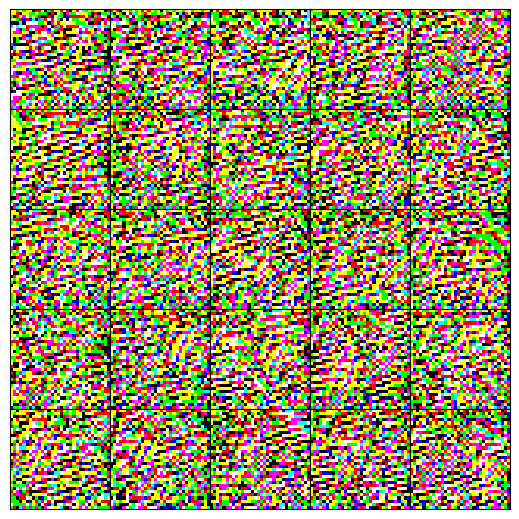

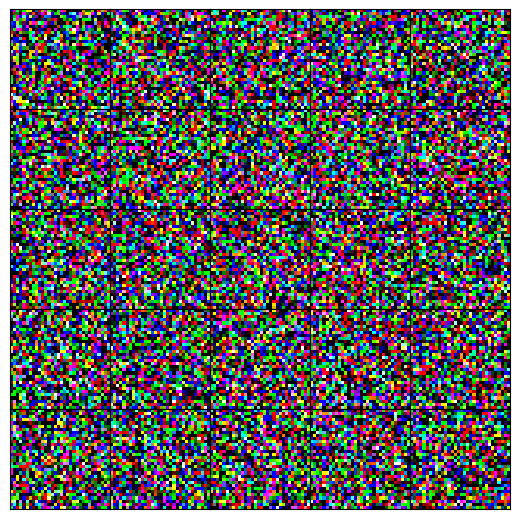

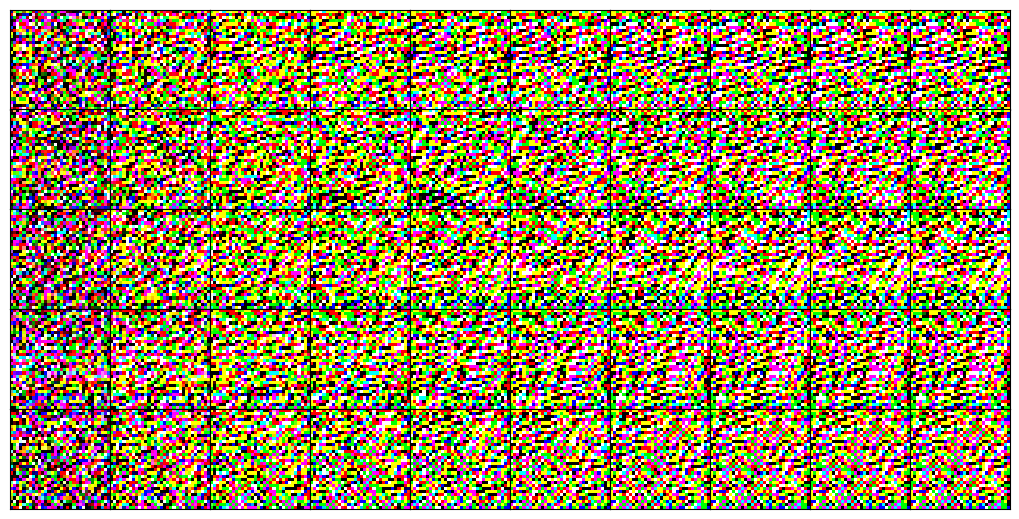

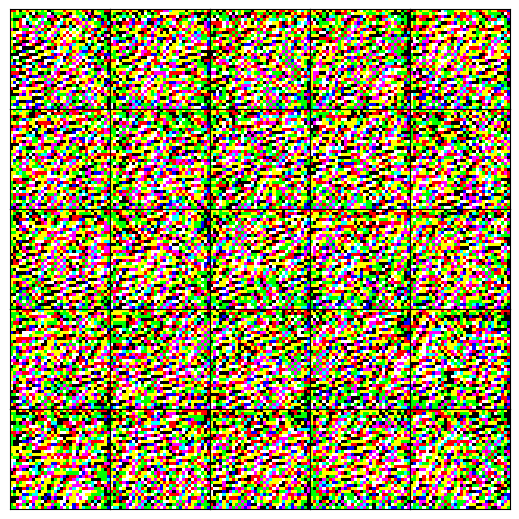

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7fcfa3d8f850>> (for post_run_cell), with arguments args (<ExecutionResult object at 7fcf7004f810, execution_count=7 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7fcf7004f6d0, raw_cell="efm = EFM(config)
net, state = efm.train(train_loa.." transformed_cell="efm = EFM(config)
net, state = efm.train(train_loa.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/windowskonon1337/sources/FieldMatching/notebooks/EFMCMGeneration.ipynb#X14sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [7]:
efm = EFM(config)
net, state = efm.train(train_loader, eval_loader,
                       net, optimizer, optimize_fn,
                       state)